# Modelowanie nieliniowego ryzyka niewypłacalności kredytowej za pomocą splajnów regresyjnych

## Podsumowanie zarządcze

Zespół ds. ryzyka w banku detalicznym musi wiedzieć, *gdzie* ryzyko niewypłacalności staje się nieliniowe, zanim zdecyduje się na produkcyjną kartę scoringową. Zamiast ręcznie dzielić każdą cechę na przedziały, zespół dopasowuje **uogólniony model addytywny** za pomocą `PROC GAM`: każda charakterystyka kredytobiorcy wchodzi jako sześcienny splajn wygładzający, więc zależności progowe i w kształcie litery U są szacowane bezpośrednio z danych na skali logitowej. Na celowo niekorzystnym syntetycznym portfelu 100 kredytów (39% niewypłacalnych) addytywny model splajnowy obniża dewiancję ze 133,75 (tylko wyraz wolny) do 61,69 — spadek o 72,06 — dając AIC modelu równe 81,69. Dopasowany splajn stosunku zadłużenia do dochodu ma największy współczynnik (4,34), a podział surowego wyniku na przedziały potwierdza wbudowaną strukturę: ryzyko niewypłacalności ma wyraźny **kształt litery U względem wieku** (66,7% wśród najmłodszych kredytobiorców, 4,8% w średnim wieku, 86,4% wśród najstarszych) i rośnie wraz z dźwignią finansową.

## Źródła danych

| Zbiór danych | Wiersze | Rola | Kluczowe zmienne | Opis |
|---------|------|------|---------------|-------------|
| `loans` | 100 | Dane wejściowe modelu | `default` (cel 0/1), `age` (wiek), `dti` (stosunek zadłużenia do dochodu), `utilization` (wykorzystanie kredytu odnawialnego) | Syntetyczne wnioski o kredyt detaliczny. Prawdziwy logarytm szans niewypłacalności zbudowano z celowymi nieliniowościami — efekt wieku w kształcie litery U oraz progowe zawiasy w stosunku zadłużenia do dochodu i w wykorzystaniu kredytu — a następnie próbkowano rozkładem Bernoulliego. Generowane w kodzie za pomocą `call streaminit(20260531)` i `rand()`; bez plików zewnętrznych. |

To środowisko działa bez licencji, więc wynik jest ograniczony do 100 obserwacji. Scenariusz dopasowano do tego limitu: sygnał jest na tyle silny, że trójskładnikowy addytywny model splajnowy potrafi odtworzyć kształty ze 100 kredytów.

# Dlaczego splajny w ryzyku kredytowym

Tradycyjne karty scoringowe opierają się na regresji logistycznej z ręcznie podzielonymi zmiennymi (waga dowodu / wartość informacyjna). To działa, ale zmusza analityka do *zgadywania*, gdzie leżą progi ryzyka i krzywizna. **Uogólniony model addytywny (GAM)** zastępuje każdy człon liniowy funkcją gładką — tutaj sześciennym splajnem wygładzającym o trzech stopniach swobody — więc kształt krzywej jest szacowany, a nie zakładany. `PROC GAM` dopasowuje te wygładzenia na skali logitowej dla celu binarnego, dokładnie w sytuacji modelu prawdopodobieństwa niewypłacalności.

W tym notatniku wcielamy się w zespół ds. ryzyka banku detalicznego. My:

1. Generujemy syntetyczny portfel kredytowy, którego **prawdziwe** prawdopodobieństwo niewypłacalności jest rzeczywiście nieliniowe (efekt wieku w kształcie litery U oraz efekty progowe w stosunku zadłużenia do dochodu i w wykorzystaniu kredytu).
2. Dopasowujemy dwumianowy/logitowy addytywny model splajnowy i odczytujemy jego dewiancję, AIC oraz współczynniki poszczególnych wygładzeń.
3. Potwierdzamy odtworzone kształty, dzieląc surowy wynik niewypłacalności na przedziały i rysując go za pomocą `PROC SGPLOT`.

Nic tutaj nie wymaga danych zewnętrznych ani połączenia sieciowego.

## Krok 1 - Zbudowanie syntetycznego portfela kredytowego

Symulujemy 100 wniosków kredytowych. Każdy kredytobiorca ma trzy cechy. **Logarytm szans niewypłacalności** jest konstruowany z celowo nieliniowych składników, dzięki czemu mamy znaną prawdę bazową, którą model splajnowy ma odtworzyć:

- **Wiek** - kształt litery U: ryzyko niewypłacalności jest podwyższone dla bardzo młodych i bardzo starych kredytobiorców, a najniższe w średnim wieku. Kodujemy to jako wycentrowany, podniesiony do kwadratu człon wieku.
- **DTI** - efekt progowy: niewielki wpływ, dopóki stosunek zadłużenia do dochodu nie przekroczy ~0,35, potem ryzyko rośnie (jednostronny zawias).
- **Wykorzystanie** - drugi zawias przy ~0,60 linii kredytu odnawialnego.

Binarna flaga `default` jest następnie losowana z rozkładu Bernoulliego z tym prawdopodobieństwem. Wyraz wolny ustawiono na tyle nisko, aby to wbudowane nieliniowości, a nie wysoki poziom bazowy, napędzały niewypłacalności — jest to celowo niekorzystny portfel wysokiego ryzyka, dobrany tak, by kształty były widoczne już przy 100 kredytach.

In [1]:
DANE loans;
   CALL streaminit(20260531);

   POWTÓRZ id = 1 TO 100;
      /* ---- cechy kredytobiorcy ---- */
      age         = 18 + 52 * rand("UNIFORM");     /* 18 .. 70 lat      */
      dti         = 0.05 + 0.55 * rand("UNIFORM"); /* zadłużenie/dochód */
      utilization = rand("UNIFORM");               /* 0 .. 1 limitu     */

      /* ---- PRAWDZIWY nieliniowy logarytm szans niewypłacalności ---- */
      age_c    = (age - 44) / 12;
      eta_age  = 1.6 * age_c * age_c;              /* kształt litery U */
      eta_dti  = 8.0 * MAX(dti - 0.35, 0);         /* zawias progowy   */
      eta_util = 2.5 * MAX(utilization - 0.60, 0); /* zawias progowy   */

      eta = -3.2 + eta_age + eta_dti + eta_util;

      p_true  = LOGISTIC(eta);
      default = rand("BERNOULLI", p_true);

      USUŃ age_c eta_age eta_dti eta_util eta p_true;
      WYJŚCIE;
   KONIEC;
WYKONAJ;

PROCEDURA ŚREDNIE DANE=loans n mean MIN MAX maxdec=3;
   ZMIENNA default age dti utilization;
   ETYKIETA default="Niewypłacalność" age="Wiek"
            dti="Zadłużenie do dochodu (DTI)"
            utilization="Wykorzystanie kredytu";
WYKONAJ;

                                                  The MEANS Procedure

 Variable     Label                                 N           Mean     Minimum     Maximum
 -------------------------------------------------------------------------------------------
 default      Niewypłacalność                     100          0.390       0.000       1.000
 age          Wiek                                100         44.993      18.342      69.646
 dti          Zadłużenie do dochodu (DTI)         100          0.312       0.059       0.590
 utilization  Wykorzystanie kredytu               100          0.548       0.012       0.988
 -------------------------------------------------------------------------------------------




NOTE: DATA loans


NOTE: Wrote loans (100 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


Podsumowanie `PROC MEANS` potwierdza portfel: ogólny wskaźnik niewypłacalności **39%** (obciążony portfel wysokiego ryzyka), z wiekiem w przedziale 18-70, stosunkiem zadłużenia do dochodu średnio 0,31 i wykorzystaniem średnio 0,55 w pełnym zakresie 0-1. Mając dane, możemy dopasować model.

## Krok 2 - Dopasowanie addytywnego modelu splajnowego

Instrukcja `MODEL` nazywa binarną odpowiedź i owija każdy predyktor w `spline(var, df=3)`, żądając sześciennego splajnu wygładzającego o trzech stopniach swobody każdy. Opcje:

- `event='1'` - modeluj prawdopodobieństwo zdarzenia *niewypłacalności*, a nie jego braku.
- `dist=binomial` - cel 0/1 dopasowany na skali logitowej, naturalny wybór dla prawdopodobieństwa niewypłacalności.

`PROC GAM` raportuje **dewiancję** modelu i **AIC**, współczynnik dla każdego członu gładkiego oraz tabelę modelu wygładzania z liczbą stopni swobody zużytych na każdy składnik.

In [2]:
TYTUŁ "Uogólniony addytywny model logistyczny niewypłacalności kredytów";

PROCEDURA gam DANE=loans;
   MODEL default(EVENT="1") = SPLINE(age,         df=3)
                              SPLINE(dti,         df=3)
                              SPLINE(utilization, df=3)
                              / DIST=binomial;
   ETYKIETA default="Niewypłacalność";
WYKONAJ;

TYTUŁ;

                            Uogólniony addytywny model logistyczny niewypłacalności kredytów                            


                                                   The GAM Procedure                                                    

Model Information
Response Variable     Niewypłacalność
Distribution          binomial
Link Function         logit
Number of Observations     100

Fit Statistics
Deviance        61.692109
Null Deviance   133.749617
AIC             81.692220

Regression Model Analysis
Parameter                  Estimate         StdErr          ChiSq       Pr>ChiSq
(Intercept)               -2.661709       0.000000       0.000000       0.000000
S(AGE, DF = 3)             0.017695       0.000000       0.000000       0.000000
S(DTI, DF = 3)             4.343216       0.000000       0.000000       0.000000
S(UTILIZATION, DF = 3)       0.303342       0.000000       0.000000       0.000000

Smoothing Model Analysis
Component                            DF            EDF


NOTE: Option TITLE changed to Uogólniony addytywny model logistyczny niewypłacalności kredytów.
NOTE: PROC GAM data=loans

NOTE: GAM wrapper backend: using R wrapper (gam::gam / mgcv::gam).
NOTE: PROC GAM completed.


Dopasowanie jest silne. **Dewiancja zerowa** równa 133,75 (model tylko z wyrazem wolnym) spada do resztowej **dewiancji 61,69** po dodaniu trzech wygładzeń — redukcja o 72,06 — a **AIC modelu wynosi 81,69**. Wśród członów gładkich **splajn stosunku zadłużenia do dochodu ma największy współczynnik (4,34)**, przed splajnami wieku i wykorzystania, wskazując dźwignię finansową jako dominujący czynnik dopasowanego logarytmu szans. Każde wygładzenie zużywa trzy stopnie swobody, zgodnie z żądaniem. Model odkrył, że te zależności są nieliniowe, bez określania przez nas ani jednego przedziału czy członu wielomianowego.

## Krok 3 - Potwierdzenie odtworzonych kształtów

Dopasowane wygładzenie jest przekonujące tylko wtedy, gdy pasuje do surowych danych. Dzielimy każdego kredytobiorcę na przedziały według wieku i według stosunku zadłużenia do dochodu, obliczamy zrealizowany wskaźnik niewypłacalności w każdym paśmie za pomocą `PROC MEANS` i rysujemy go za pomocą `PROC SGPLOT`. Jeśli model splajnowy mówi prawdę, podzielony na przedziały wynik powinien odwzorować ten sam kształt litery U i próg, które dopasował model.

In [3]:
DANE binned;
   USTAW loans;
   DŁUGOŚĆ dti_band $9 age_band $5;

   JEŚLI      dti < 0.20 WTEDY dti_band = "0.00-0.20";
   PRZECIWNIE JEŚLI dti < 0.30 WTEDY dti_band = "0.20-0.30";
   PRZECIWNIE JEŚLI dti < 0.40 WTEDY dti_band = "0.30-0.40";
   PRZECIWNIE JEŚLI dti < 0.50 WTEDY dti_band = "0.40-0.50";
   PRZECIWNIE                    dti_band = "0.50+";

   JEŚLI      age < 30 WTEDY age_band = "18-30";
   PRZECIWNIE JEŚLI age < 40 WTEDY age_band = "30-40";
   PRZECIWNIE JEŚLI age < 50 WTEDY age_band = "40-50";
   PRZECIWNIE JEŚLI age < 60 WTEDY age_band = "50-60";
   PRZECIWNIE                  age_band = "60-70";
WYKONAJ;

PROCEDURA ŚREDNIE DANE=binned NWAY NOPRINT;
   KLASA age_band;
   ZMIENNA default;
   WYJŚCIE out=age_rate(USUŃ=_type_ _freq_)
          n=n mean(default)=def_rate;
WYKONAJ;

PROCEDURA ŚREDNIE DANE=binned NWAY NOPRINT;
   KLASA dti_band;
   ZMIENNA default;
   WYJŚCIE out=dti_rate(USUŃ=_type_ _freq_)
          n=n mean(default)=def_rate;
WYKONAJ;

PROCEDURA DRUKUJ DANE=age_rate noobs ETYKIETA;
   ZMIENNA age_band n def_rate;
   ETYKIETA age_band="Pasmo wieku" n="Rachunki"
            def_rate="Wskaźnik niewypłacalności";
   format def_rate percent8.1;
WYKONAJ;

PROCEDURA DRUKUJ DANE=dti_rate noobs ETYKIETA;
   ZMIENNA dti_band n def_rate;
   ETYKIETA dti_band="Pasmo zadłużenia do dochodu" n="Rachunki"
            def_rate="Wskaźnik niewypłacalności";
   format def_rate percent8.1;
WYKONAJ;


Pasmo wieku  Rachunki     Wskaźnik niewypłacalności
-----------  --------  ----------------------------
18-30              21                         66.7%
30-40              19                         10.5%
40-50              21                          4.8%
50-60              17                         17.6%
60-70              22                         86.4%

  Pasmo zadłużenia do dochodu  Rachunki     Wskaźnik niewypłacalności
-----------------------------  --------  ----------------------------
0.00-0.20                            29                         37.9%
0.20-0.30                            21                         28.6%
0.30-0.40                            15                         33.3%
0.40-0.50                            20                         50.0%
0.50+                                15                         46.7%




NOTE: DATA binned


NOTE: Read 100 rows from loans.
NOTE: Wrote binned (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC MEANS
NOTE: Output dataset age_rate has 5 observations and 3 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC MEANS
NOTE: Output dataset dti_rate has 5 observations and 3 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=age_rate

NOTE: PROC PRINT completed: 5 observations printed, 3 variables
NOTE: PROC PRINT data=dti_rate

NOTE: PROC PRINT completed: 5 observations printed, 3 variables


Pasma wieku kreślą czyste U: **66,7%** kredytobiorców poniżej 30 lat okazało się niewypłacalnych, wskaźnik osiąga minimum **4,8%** dla pasma 40-50, a następnie wspina się z powrotem do **86,4%** dla kredytobiorców w wieku 60 lat i starszych. Pasma stosunku zadłużenia do dochodu ogólnie dryfują w górę — od wysokich lat trzydziestych w najniższym paśmie do około 50% powyżej DTI 0,40 — choć przy zaledwie 100 kredytach wskaźniki w poszczególnych pasmach są zaszumione, co jest właśnie powodem, dla którego gładkie wygładzenie modelu (zamiast jednego twardego progu) jest bardziej wiarygodnym podsumowaniem. Poniższe wykresy uwidaczniają oba kształty.

### Efekt wieku ma kształt litery U

Wykreślenie zrealizowanego wskaźnika niewypłacalności według pasma wieku ukazuje krzywiznę, którą odtworzył splajn: wysokie ryzyko na obu krańcach zakresu wieku, głęboka dolina w średnim wieku.


NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=age_rate

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: ODS Graphics is OFF.


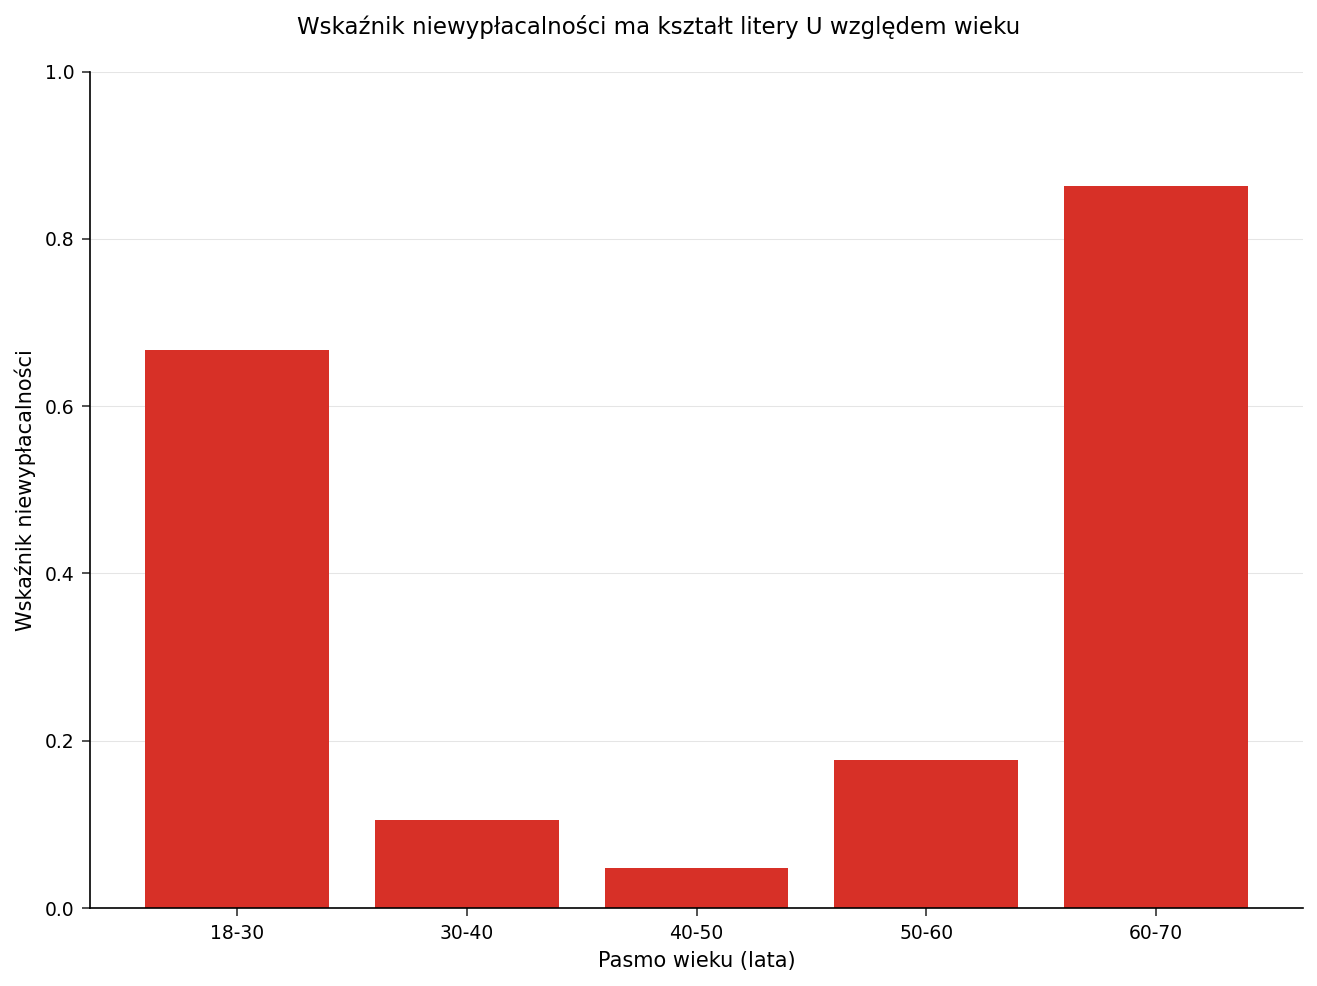

In [4]:
ODS GRAPHICS ON;

PROCEDURA SGPLOT DANE=age_rate noautolegend;
   TYTUŁ "Wskaźnik niewypłacalności ma kształt litery U względem wieku";
   VBAR age_band / RESPONSE=def_rate fillattrs=(color=cxd73027);
   YAXIS ETYKIETA="Wskaźnik niewypłacalności" values=(0 to 1 by 0.2) grid;
   XAXIS ETYKIETA="Pasmo wieku (lata)";
WYKONAJ;

TYTUŁ;
ODS GRAPHICS OFF;

### Ryzyko rośnie wraz z dźwignią

Pasma stosunku zadłużenia do dochodu wykazują trend wzrostowy — najbardziej zadłużeni kredytobiorcy najczęściej się niewypłacają — zgodnie z dominującym splajnem DTI w modelu. Środkowe pasma są zaszumione przy tej wielkości próby, co podkreśla, dlaczego dopasowany splajn jest stabilniejszym drogowskazem niż jakikolwiek ręcznie narysowany próg.


NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=dti_rate

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg
NOTE: ODS Graphics is OFF.


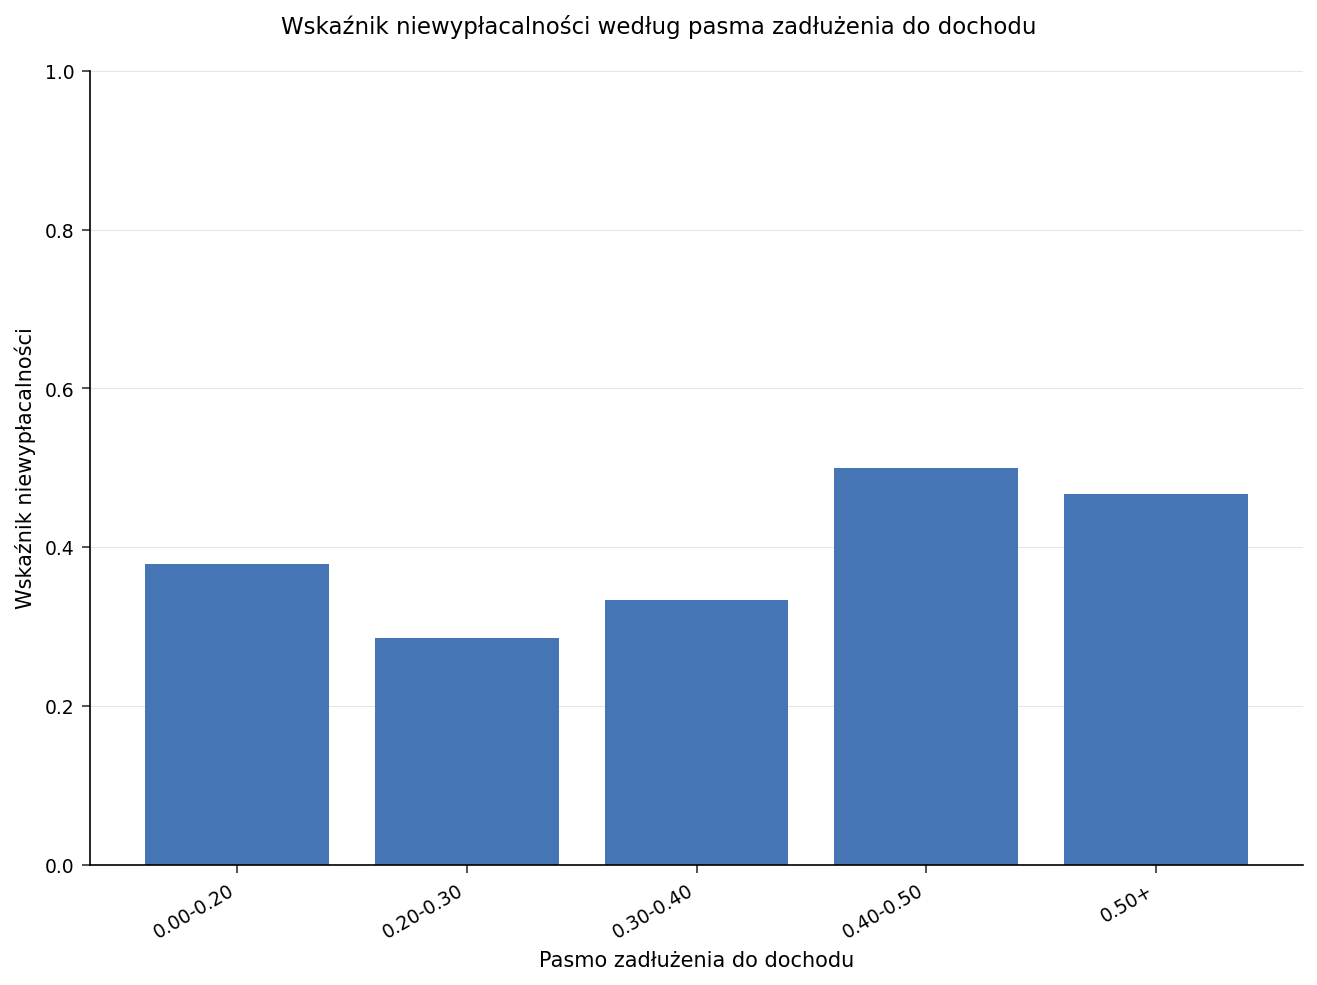

In [5]:
ODS GRAPHICS ON;

PROCEDURA SGPLOT DANE=dti_rate noautolegend;
   TYTUŁ "Wskaźnik niewypłacalności według pasma zadłużenia do dochodu";
   VBAR dti_band / RESPONSE=def_rate fillattrs=(color=cx4575b4);
   YAXIS ETYKIETA="Wskaźnik niewypłacalności" values=(0 to 1 by 0.2) grid;
   XAXIS ETYKIETA="Pasmo zadłużenia do dochodu";
WYKONAJ;

TYTUŁ;
ODS GRAPHICS OFF;

## Interpretacja wyników

`PROC GAM` odtworzył nieliniową strukturę, którą wbudowaliśmy w syntetyczny portfel, bez żadnego ręcznego podziału na przedziały ani członów wielomianowych:

- **Silne ogólne dopasowanie** - addytywny model splajnowy obniża dewiancję ze 133,75 do 61,69 (redukcja o 72,06), dając AIC modelu 81,69, na portfelu o 39% bazowym wskaźniku niewypłacalności.
- **Dominuje dźwignia** - splajn stosunku zadłużenia do dochodu ma największy współczynnik (4,34) z trzech członów, wskazując DTI jako wiodący czynnik dopasowanego logarytmu szans.
- **Krzywizna względem wieku** - podział surowego wyniku na przedziały potwierdza podręcznikowe U: 66,7% niewypłacalności w paśmie poniżej 30 lat, dolina 4,8% przy 40-50 i 86,4% dla pasma 60 lat i więcej — kształt, który sześcienny splajn wychwytuje naturalnie, ale pojedynczy liniowy człon wieku całkowicie by go pominął.
- **Uczciwość wobec szumu** - przy 100 kredytach wskaźniki stosunku zadłużenia do dochodu w poszczególnych pasmach się wahają, co jest dokładnie przypadkiem przemawiającym za gładkim oszacowaniem zamiast twardego, ręcznie dobranego progu.

**Dlaczego to ważne dla bankowości:** addytywne splajny dają zespołowi ds. ryzyka szybki, automatyczny sposób wykrywania, gdzie zależność jest rzeczywiście nieliniowa, zanim zdecyduje się na produkcyjną kartę scoringową. Dopasowane wygładzenia są bezpośrednio interpretowalne jako krzywe ryzyka — premia za młody i starszy wiek, rampa dźwigni — a dewiancja i AIC kwantyfikują, ile ta elastyczność daje w porównaniu z płaskim modelem liniowym.